# Предсказание атрибутов узлов с использованием графовых нейронных сетей

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Курс "Машинное обучение на графах", Лекции 4-5 "Графовые нейронные сети"
* Документация:
    * https://docs.dgl.ai/en/latest/tutorials/blitz/2_dglgraph.html
    * https://docs.dgl.ai/en/latest/tutorials/blitz/1_introduction.html
    * https://docs.dgl.ai/generated/dgl.nn.pytorch.conv.GraphConv.html#dgl.nn.pytorch.conv.GraphConv
    * https://docs.dgl.ai/api/python/dgl.data.html

In [1]:
%pip uninstall numpy dgl torch -y
%pip install "numpy<2" "dgl>=2.0" "torch>=2.0"
%pip install torchdata==0.6.0


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 118.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 

## Вопросы для совместного обсуждения

1\. Обсудите основные шаги для решения задачи предсказания атрибутов узлов при помощи графовых нейронных сетей.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите граф `CoraGraphDataset` из `dgl.data`. Решите задачу классификации узлов графа, используя только полносвязные слои `torch.nn.Linear` (создайте модель из двух слоев). Обратите внимание, что настройка весов модели должна проводиться только на основе примеров из обучающей выборки. Посчитайте и выведите на экран значение `accuracy` на тестовой выборке.

- [ ] Проверено на семинаре

In [1]:
import dgl
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


In [2]:
dataset = dgl.data.CoraGraphDataset()
graph = dataset[0]

features = graph.ndata['feat']
labels = graph.ndata['label']
train_mask = graph.ndata['train_mask']
test_mask = graph.ndata['test_mask']

num_feats = features.shape[1]
num_classes = dataset.num_classes

/root/.dgl/cora_v2.zip:   0%|          | 0.00/132k [00:00<?, ?B/s]

Extracting file to /root/.dgl/cora_v2_d697a464
Finished data loading and preprocessing.
  NumNodes: 2708
  NumEdges: 10556
  NumFeats: 1433
  NumClasses: 7
  NumTrainingSamples: 140
  NumValidationSamples: 500
  NumTestSamples: 1000
Done saving data into cached files.


In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [5]:
hidden_dim = 16
learning_rate = 0.01
epochs = 200

In [6]:
model = MLP(num_feats, hidden_dim, num_classes)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(epochs):
    model.train()
    logits = model(features)
    loss = loss_fn(logits[train_mask], labels[train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 20/200, Loss: 1.7074
Epoch 40/200, Loss: 1.0581
Epoch 60/200, Loss: 0.4165
Epoch 80/200, Loss: 0.1427
Epoch 100/200, Loss: 0.0640
Epoch 120/200, Loss: 0.0376
Epoch 140/200, Loss: 0.0257
Epoch 160/200, Loss: 0.0190
Epoch 180/200, Loss: 0.0148
Epoch 200/200, Loss: 0.0119


In [7]:
model.eval()
with torch.no_grad():
    logits = model(features)
    predictions = torch.argmax(logits[test_mask], dim=1)
    accuracy = (predictions == labels[test_mask]).float().mean()
    print(f'\nTest Accuracy: {accuracy.item():.4f}')


Test Accuracy: 0.4590


<p class="task" id="2"></p>

2\. Решите задачу 1, используя два слоя `dgl.nn.GraphConv` вместо полносвязных слоев `torch.nn.Linear`.

- [ ] Проверено на семинаре

In [8]:
from dgl.nn.pytorch import GraphConv

In [9]:
class GCN(nn.Module):
    def __init__(self, in_feats, h_feats, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GraphConv(in_feats, h_feats)
        self.conv2 = GraphConv(h_feats, num_classes)

    def forward(self, graph, in_feat):
        h = self.conv1(graph, in_feat)
        h = F.relu(h)
        h = self.conv2(graph, h)
        return h

In [10]:
hidden_dim = 16
learning_rate = 0.01
epochs = 200

In [11]:
model = GCN(num_feats, hidden_dim, num_classes)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(epochs):
    model.train()
    # В GraphConv передаем граф и признаки
    logits = model(graph, features)
    loss = loss_fn(logits[train_mask], labels[train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 20/200, Loss: 1.6098
Epoch 40/200, Loss: 0.9733
Epoch 60/200, Loss: 0.4374
Epoch 80/200, Loss: 0.1910
Epoch 100/200, Loss: 0.0960
Epoch 120/200, Loss: 0.0560
Epoch 140/200, Loss: 0.0368
Epoch 160/200, Loss: 0.0262
Epoch 180/200, Loss: 0.0198
Epoch 200/200, Loss: 0.0156


In [12]:
model.eval()
with torch.no_grad():
    logits = model(graph, features)
    predictions = torch.argmax(logits[test_mask], dim=1)
    accuracy = (predictions == labels[test_mask]).float().mean()
    print(f'\nTest Accuracy (GCN): {accuracy.item():.4f}')


Test Accuracy (GCN): 0.7580


<p class="task" id="3"></p>

3\. Воспользовавшись необученной моделью из предыдущего задания, получите прогнозы для всех узлов графа. Уменьшите размерность полученных прогнозов до 2 при помощи алгоритма t-SNE (`sklearn.manifold.TSNE`). Визуализируйте точки на плоскости, используя полученные значения в качестве координат. Раскрасьте точки в цвета, соответствующим меткам узлов.

Повторите данную процедуру, используя обученную модель. Сравните результаты и сделайте выводы.

- [ ] Проверено на семинаре

In [21]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [22]:
class GCN(nn.Module):
    def __init__(self, in_feats, h_feats, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GraphConv(in_feats, h_feats)
        self.conv2 = GraphConv(h_feats, num_classes)

    def forward(self, graph, in_feat):
        h = self.conv1(graph, in_feat)
        h = F.relu(h)
        h = self.conv2(graph, h)
        return h

hidden_dim = 16
learning_rate = 0.01
epochs = 200
tsne_random_state = 42 # для воспроизводимости t-SNE

In [23]:
def visualize_embeddings(model, graph, features, labels, title, trained_model=False):
    model.eval()
    with torch.no_grad():
        # Получаем "прогнозы" (выходы последнего слоя, они же эмбеддинги узлов)
        node_embeddings = model(graph, features)

    # Уменьшение размерности с помощью t-SNE
    tsne = TSNE(n_components=2, random_state=tsne_random_state, perplexity=30, n_iter=300)
    embeddings_2d = tsne.fit_transform(node_embeddings.cpu().numpy())

    # Визуализация
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels.cpu().numpy(), cmap='viridis', s=10)
    plt.title(title)
    plt.xlabel("t-SNE измерение 1")
    plt.ylabel("t-SNE измерение 2")
    # Добавим легенду, если классов не слишком много
    if num_classes <= 10:
         handles, _ = scatter.legend_elements(prop="colors")
         legend_labels = [f'Class {i}' for i in range(num_classes)]
         plt.legend(handles, legend_labels, title="Classes")
    plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


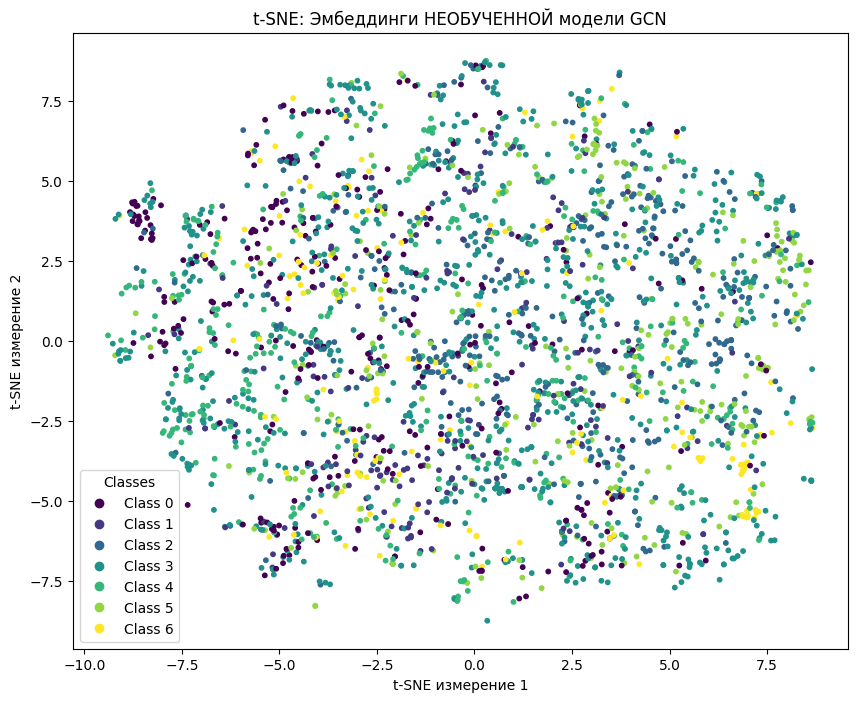

In [24]:
untrained_model = GCN(num_feats, hidden_dim, num_classes)
visualize_embeddings(untrained_model, graph, features, labels, "t-SNE: Эмбеддинги НЕОБУЧЕННОЙ модели GCN")

In [25]:
trained_model = GCN(num_feats, hidden_dim, num_classes)
optimizer = optim.Adam(trained_model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

print("\nОбучение модели GCN...")
for epoch in range(epochs):
    trained_model.train()
    logits = trained_model(graph, features)
    loss = loss_fn(logits[train_mask], labels[train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')


Обучение модели GCN...
Epoch 50/200, Loss: 0.6605
Epoch 100/200, Loss: 0.0926
Epoch 150/200, Loss: 0.0302
Epoch 200/200, Loss: 0.0155


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


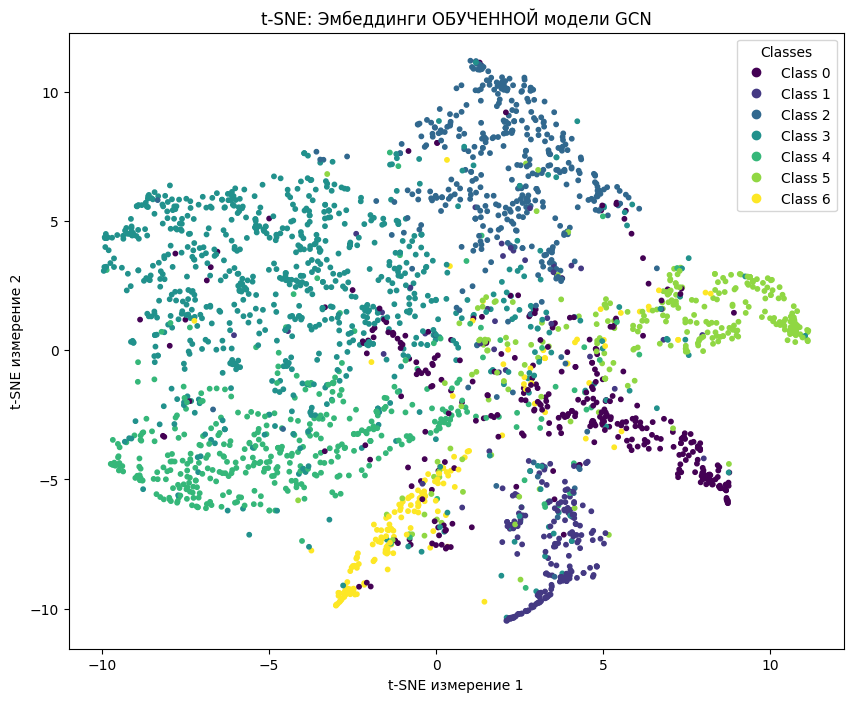

In [26]:
visualize_embeddings(trained_model, graph, features, labels, "t-SNE: Эмбеддинги ОБУЧЕННОЙ модели GCN", trained_model=True)

<p class="task" id="4"></p>

4\.  Предыдущие решения не используют узлы, находящиеся в валидационном множестве. Решите задачу 2, используя валидационное множество для выполнения ранней остановки.

- [ ] Проверено на семинаре

In [27]:
import copy

In [33]:
dataset = dgl.data.CoraGraphDataset()
graph = dataset[0]

features = graph.ndata['feat']
labels = graph.ndata['label']
train_mask = graph.ndata['train_mask']
val_mask = graph.ndata['val_mask'] # Используем валидационную маску
test_mask = graph.ndata['test_mask']

num_feats = features.shape[1]
num_classes = dataset.num_classes

  NumNodes: 2708
  NumEdges: 10556
  NumFeats: 1433
  NumClasses: 7
  NumTrainingSamples: 140
  NumValidationSamples: 500
  NumTestSamples: 1000
Done loading data from cached files.


In [34]:
class GCN(nn.Module):
    def __init__(self, in_feats, h_feats, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GraphConv(in_feats, h_feats)
        self.conv2 = GraphConv(h_feats, num_classes)

    def forward(self, graph, in_feat):
        h = self.conv1(graph, in_feat)
        h = F.relu(h)
        h = self.conv2(graph, h)
        return h

In [35]:
hidden_dim = 16
learning_rate = 0.01
epochs = 300
patience = 10

In [36]:
model = GCN(num_feats, hidden_dim, num_classes)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

In [37]:
best_val_accuracy = 0.0
epochs_no_improve = 0
best_model_state = None

In [38]:
for epoch in range(epochs):
    model.train()
    logits = model(graph, features)
    loss = loss_fn(logits[train_mask], labels[train_mask])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Валидация
    model.eval()
    with torch.no_grad():
        val_logits = model(graph, features)
        val_predictions = torch.argmax(val_logits[val_mask], dim=1)
        val_accuracy = (val_predictions == labels[val_mask]).float().mean().item()
        val_loss = loss_fn(val_logits[val_mask], labels[val_mask]).item()


    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        # Сохраняем состояние лучшей модели
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f'\nРанняя остановка на эпохе {epoch+1}. Лучшая Val Accuracy: {best_val_accuracy:.4f}')
        break

Epoch 10/300, Train Loss: 1.8032, Val Loss: 1.8653, Val Accuracy: 0.6380
Epoch 20/300, Train Loss: 1.5530, Val Loss: 1.7383, Val Accuracy: 0.6740
Epoch 30/300, Train Loss: 1.2344, Val Loss: 1.5686, Val Accuracy: 0.6860
Epoch 40/300, Train Loss: 0.9002, Val Loss: 1.3676, Val Accuracy: 0.7080
Epoch 50/300, Train Loss: 0.6126, Val Loss: 1.1832, Val Accuracy: 0.7260
Epoch 60/300, Train Loss: 0.4042, Val Loss: 1.0408, Val Accuracy: 0.7420
Epoch 70/300, Train Loss: 0.2681, Val Loss: 0.9455, Val Accuracy: 0.7520
Epoch 80/300, Train Loss: 0.1826, Val Loss: 0.8873, Val Accuracy: 0.7480

Ранняя остановка на эпохе 83. Лучшая Val Accuracy: 0.7560


In [39]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [40]:
model.eval()
with torch.no_grad():
    test_logits = model(graph, features)
    test_predictions = torch.argmax(test_logits[test_mask], dim=1)
    test_accuracy = (test_predictions == labels[test_mask]).float().mean()
    print(f'\nTest Accuracy (GCN с ранней остановкой): {test_accuracy.item():.4f}')


Test Accuracy (GCN с ранней остановкой): 0.7780


<p class="task" id="5"></p>

5\. Повторите решение задачи 4, сравнив несколько различных слоев:
* GraphConv
* SAGEConv (укажите `aggregator_type="mean"`)
* GATConv (выберите для первого слоя `num_heads > 1`)

Выведите результат в виде таблицы:

| Модель    | Loss на обучении | Acc на обучении | Acc на тесте | Кол-во эпох до ранней остановки |
|-----------|------------------|-----------------|--------------|-------------|
| GraphConv |                  |                 |              |             |
| SAGEConv  |                  |                 |              |             |
| GATConv   |                  |                 |              |             |


- [ ] Проверено на семинаре

In [41]:
from dgl.nn.pytorch import GraphConv, SAGEConv, GATConv
import pandas as pd

In [42]:
dataset = dgl.data.CoraGraphDataset()
graph = dataset[0]

features = graph.ndata['feat']
labels = graph.ndata['label']
train_mask = graph.ndata['train_mask']
val_mask = graph.ndata['val_mask']
test_mask = graph.ndata['test_mask']

num_feats = features.shape[1]
num_classes = dataset.num_classes

  NumNodes: 2708
  NumEdges: 10556
  NumFeats: 1433
  NumClasses: 7
  NumTrainingSamples: 140
  NumValidationSamples: 500
  NumTestSamples: 1000
Done loading data from cached files.


In [43]:
HIDDEN_DIM = 16
LR = 0.01
EPOCHS = 300
PATIENCE = 20 # Увеличено для более стабильных результатов, особенно для GAT
GAT_H_FEATS_PER_HEAD = 8
GAT_NUM_HEADS_L1 = 2

In [44]:
class GCN_model(nn.Module):
    def __init__(self, in_feats, h_feats, num_classes):
        super(GCN_model, self).__init__()
        self.conv1 = GraphConv(in_feats, h_feats, activation=F.relu)
        self.conv2 = GraphConv(h_feats, num_classes)

    def forward(self, graph, in_feat):
        h = self.conv1(graph, in_feat)
        h = self.conv2(graph, h)
        return h

class SAGE_model(nn.Module):
    def __init__(self, in_feats, h_feats, num_classes):
        super(SAGE_model, self).__init__()
        self.conv1 = SAGEConv(in_feats, h_feats, aggregator_type='mean')
        self.conv2 = SAGEConv(h_feats, num_classes, aggregator_type='mean')

    def forward(self, graph, in_feat):
        h = F.relu(self.conv1(graph, in_feat))
        h = self.conv2(graph, h)
        return h

In [45]:
class GAT_model(nn.Module):
    def __init__(self, in_feats, h_feats_per_head, num_classes, num_heads_l1):
        super(GAT_model, self).__init__()
        self.h_feats_per_head = h_feats_per_head
        self.num_heads_l1 = num_heads_l1

        # GATConv применяет LeakyReLU по умолчанию, если activation=None
        self.conv1 = GATConv(in_feats, self.h_feats_per_head, num_heads=self.num_heads_l1,
                             feat_drop=0.0, attn_drop=0.0, allow_zero_in_degree=True)
        # Выход conv1: (N, num_heads_l1, h_feats_per_head)

        self.conv2 = GATConv(self.h_feats_per_head * self.num_heads_l1, num_classes, num_heads=1,
                             feat_drop=0.0, attn_drop=0.0, allow_zero_in_degree=True)
        # Выход conv2: (N, 1, num_classes)

    def forward(self, graph, inputs):
        h = self.conv1(graph, inputs)
        # h уже активирован LeakyReLU внутри GATConv
        h = h.view(-1, self.h_feats_per_head * self.num_heads_l1)
        h = F.relu(h) # Добавим ReLU для сопоставимости с другими моделями (GAT часто использует ELU или LeakyReLU)

        logits = self.conv2(graph, h)
        logits = logits.squeeze(1)
        return logits

In [46]:
def train_and_evaluate(model_name, model_instance, graph, features, labels,
                       train_mask, val_mask, test_mask,
                       lr, epochs, patience):
    model = model_instance
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    best_val_accuracy = 0.0
    epochs_no_improve = 0
    best_model_state = None
    stopped_epoch = epochs # Эпоха, на которой остановились (1-индексированная)

    best_train_loss_at_best_val = float('inf')
    best_train_acc_at_best_val = 0.0

    actual_epochs_ran = 0

    for epoch in range(epochs):
        actual_epochs_ran = epoch + 1
        model.train()
        logits_train = model(graph, features)
        train_loss = loss_fn(logits_train[train_mask], labels[train_mask])

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        train_preds = torch.argmax(logits_train[train_mask], dim=1)
        train_acc = (train_preds == labels[train_mask]).float().mean().item()

        model.eval()
        with torch.no_grad():
            logits_val = model(graph, features)
            # val_loss = loss_fn(logits_val[val_mask], labels[val_mask]).item() # Не требуется для таблицы
            val_predictions = torch.argmax(logits_val[val_mask], dim=1)
            val_accuracy = (val_predictions == labels[val_mask]).float().mean().item()

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            stopped_epoch = epoch + 1 # Эпоха (1-индексированная), на которой достигнуто лучшее
            best_train_loss_at_best_val = train_loss.item()
            best_train_acc_at_best_val = train_acc
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'{model_name}: Ранняя остановка на эпохе {epoch+1}. Лучшая Val Acc: {best_val_accuracy:.4f}')
            # stopped_epoch уже установлен на эпоху лучшей модели
            break

    if not best_model_state and actual_epochs_ran > 0 : # Если не было улучшений, но обучение шло
        print(f'{model_name}: Не было улучшений на валидации. Используется модель последней эпохи.')
        best_model_state = copy.deepcopy(model.state_dict()) # Берем последнюю
        stopped_epoch = actual_epochs_ran
        # Метрики на трейне будут от последней эпохи
        logits_train_last = model(graph, features) # Нужны последние логиты для train_loss/acc
        best_train_loss_at_best_val = loss_fn(logits_train_last[train_mask], labels[train_mask]).item()
        train_preds_last = torch.argmax(logits_train_last[train_mask], dim=1)
        best_train_acc_at_best_val = (train_preds_last == labels[train_mask]).float().mean().item()


    if best_model_state:
        model.load_state_dict(best_model_state)
    else: # Если 0 эпох или что-то совсем пошло не так
        print(f"Предупреждение для {model_name}: best_model_state не был установлен.")
        # В этом случае метрики будут начальными (inf, 0)

    model.eval()
    with torch.no_grad():
        logits_test = model(graph, features)
        test_predictions = torch.argmax(logits_test[test_mask], dim=1)
        test_accuracy = (test_predictions == labels[test_mask]).float().mean().item()

    return {
        "Model": model_name,
        "Loss на обучении": best_train_loss_at_best_val,
        "Acc на обучении": best_train_acc_at_best_val,
        "Acc на тесте": test_accuracy,
        "Кол-во эпох до ранней остановки": stopped_epoch
    }

In [47]:
results_list = []

In [48]:
# GraphConv
gcn = GCN_model(num_feats, HIDDEN_DIM, num_classes)
results_gcn = train_and_evaluate("GraphConv", gcn, graph, features, labels,
                                 train_mask, val_mask, test_mask,
                                 LR, EPOCHS, PATIENCE)
results_list.append(results_gcn)
print(f"GraphConv Test Acc: {results_gcn['Acc на тесте']:.4f}\n")

GraphConv: Ранняя остановка на эпохе 70. Лучшая Val Acc: 0.7760
GraphConv Test Acc: 0.7920



In [49]:
# SAGEConv
sage = SAGE_model(num_feats, HIDDEN_DIM, num_classes)
results_sage = train_and_evaluate("SAGEConv", sage, graph, features, labels,
                                  train_mask, val_mask, test_mask,
                                  LR, EPOCHS, PATIENCE)
results_list.append(results_sage)
print(f"SAGEConv Test Acc: {results_sage['Acc на тесте']:.4f}\n")

SAGEConv: Ранняя остановка на эпохе 48. Лучшая Val Acc: 0.7380
SAGEConv Test Acc: 0.7250



In [50]:
# GATConv
gat = GAT_model(num_feats, GAT_H_FEATS_PER_HEAD, num_classes, GAT_NUM_HEADS_L1)
results_gat = train_and_evaluate("GATConv", gat, graph, features, labels,
                                 train_mask, val_mask, test_mask,
                                 LR, EPOCHS, PATIENCE)
results_list.append(results_gat)
print(f"GATConv Test Acc: {results_gat['Acc на тесте']:.4f}\n")

GATConv: Ранняя остановка на эпохе 73. Лучшая Val Acc: 0.7620
GATConv Test Acc: 0.7920



In [51]:
df_results = pd.DataFrame(results_list)
df_results = df_results[["Model", "Loss на обучении", "Acc на обучении", "Acc на тесте", "Кол-во эпох до ранней остановки"]]

print("\nСводная таблица результатов:")
print(df_results.to_string(index=False, float_format="%.4f"))


Сводная таблица результатов:
    Model  Loss на обучении  Acc на обучении  Acc на тесте  Кол-во эпох до ранней остановки
GraphConv            0.6036           0.9857        0.7920                               50
 SAGEConv            0.3380           1.0000        0.7250                               28
  GATConv            0.4251           0.9929        0.7920                               53
